First 10 rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   
5    -122.25     37.85                52.0        919.0           213.0   
6    -122.25     37.84                52.0       2535.0           489.0   
7    -122.25     37.84                52.0       3104.0           687.0   
8    -122.26     37.84                42.0       2555.0           665.0   
9    -122.25     37.84                52.0       3549.0           707.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1

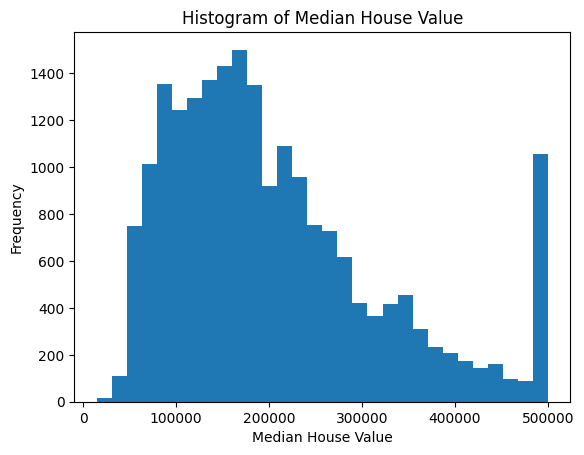

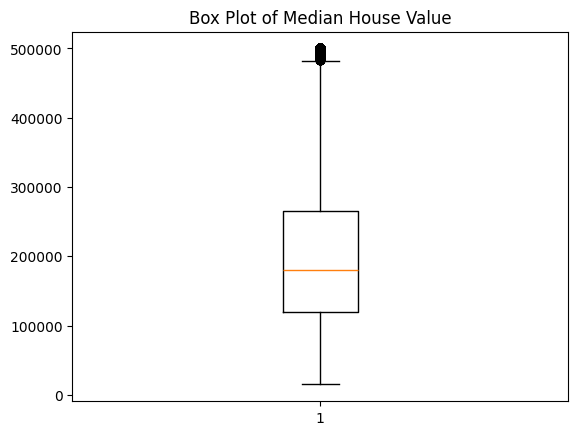


Missing Percentage per Column:
longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64


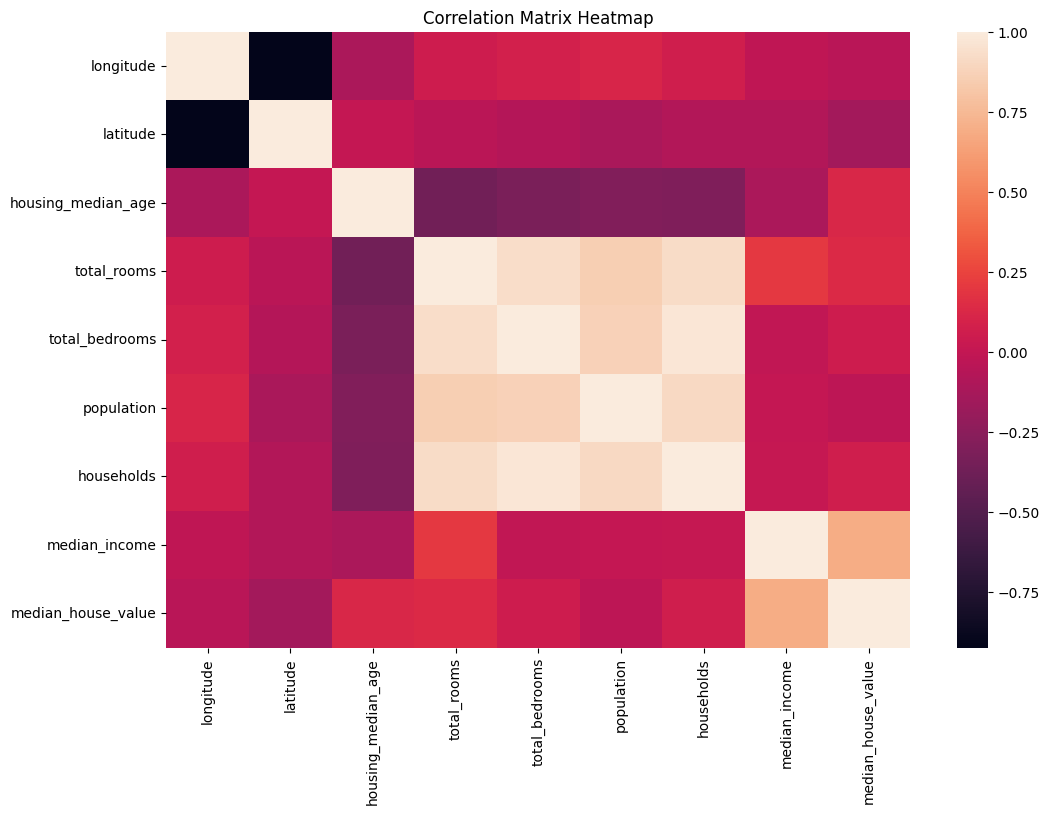

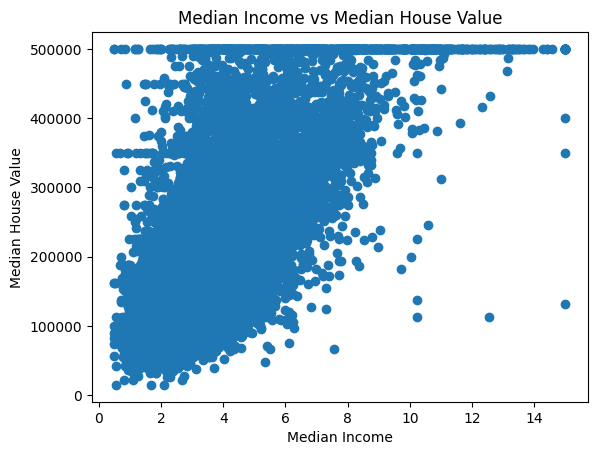


Top 3 Positively Correlated Features:
median_income         0.690647
total_rooms           0.133989
housing_median_age    0.103706
Name: median_house_value, dtype: float64

Most Negatively Correlated Feature:
latitude   -0.142983
Name: median_house_value, dtype: float64

Model Performance:
RMSE: 70040.67679908364
MAE: 50857.043017429016
R2 Score: 0.6256362335780752


In [6]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 2. Load Dataset

data = pd.read_csv("housing.csv")

# 3. Display first 10 rows & data types
print("First 10 rows:")
print(data.head(10))

print("\nData Types:")
print(data.dtypes)

# 4. Basic Statistics
numeric_stats = data.describe().T
numeric_stats = numeric_stats[['mean', '50%', 'std', 'min', 'max']]
numeric_stats.rename(columns={'50%': 'median'}, inplace=True)

print("\nBasic Statistics:")
print(numeric_stats)

# 5. Distribution of Target Variable
plt.figure()
plt.hist(data['median_house_value'], bins=30)
plt.title("Histogram of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.boxplot(data['median_house_value'])
plt.title("Box Plot of Median House Value")
plt.show()

# 6. Missing Values Percentage
missing_percent = (data.isnull().sum() / len(data)) * 100
print("\nMissing Percentage per Column:")
print(missing_percent)

# 7. Handle Missing Values
# Median is used because the distribution is skewed and robust to outliers
data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].median())

# 8. One-Hot Encoding
data_encoded = pd.get_dummies(data, columns=['ocean_proximity'])

# 9. MinMax Scaling
minmax_scaler = MinMaxScaler(feature_range=(0, 1))

numeric_cols = data_encoded.select_dtypes(include=[np.number]).columns
data_encoded[numeric_cols] = minmax_scaler.fit_transform(data_encoded[numeric_cols])

# 10. Stratified Sampling (based on median_income)
data['income_cat'] = pd.cut(
    data['median_income'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(data, data['income_cat']):
    strat_train_set = data.loc[train_index]
    strat_test_set = data.loc[test_index]

# Remove helper column
strat_train_set = strat_train_set.drop("income_cat", axis=1)
strat_test_set = strat_test_set.drop("income_cat", axis=1)

# 11. Correlation Matrix
corr_matrix = strat_train_set.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=False)
plt.title("Correlation Matrix Heatmap")
plt.show()

# 12. Scatter Plot
plt.figure()
plt.scatter(strat_train_set['median_income'],
            strat_train_set['median_house_value'])
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")
plt.show()

# 13. Random 80-20 Split
train_set, test_set = train_test_split(data, test_size=0.2, random_state=42)

# 14. Feature Correlations with Target
corr = train_set.corr(numeric_only=True)
corr_target = corr['median_house_value'].sort_values(ascending=False)

print("\nTop 3 Positively Correlated Features:")
print(corr_target[1:4])

print("\nMost Negatively Correlated Feature:")
print(corr_target.tail(1))

# 15. Prepare Data for Regression
X_train = train_set.drop("median_house_value", axis=1)
y_train = train_set["median_house_value"]

X_test = test_set.drop("median_house_value", axis=1)
y_test = test_set["median_house_value"]

# One-hot encode categorical
X_train = pd.get_dummies(X_train, columns=['ocean_proximity'])
X_test = pd.get_dummies(X_test, columns=['ocean_proximity'])

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 16. Standard Scaling
scaler = StandardScaler()

num_cols = X_train.select_dtypes(include=[np.number]).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 17. Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

# 18. Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\nModel Performance:")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)
